## Content

* Using tools with LLMs
* Langchain Agent models
* LangGraph Agent models
* CrewAI Agent models


## Using tools with LLMs

Let's review how to use the Chat Completions API alongside external functions to enhance the capabilities of GPT models.

The tools parameter in the Chat Completion API is optional and allows you to provide function specifications. This enables the model to generate function arguments that match the given specifications. However, the API itself does not execute these functions; it is the responsibility of developers to handle function execution using the model's outputs.

When functions are included in the tools parameter, the model will automatically decide when to use them unless specified otherwise. To force the API to use a specific function, you can set the tool_choice parameter to {"type": "function", "function": {"name": "my_function"}}. Alternatively, you can prevent the API from using any function by setting tool_choice to "none". If a function is used, the response will include "finish_reason": "tool_calls" along with a tool_calls object, which contains the function's name and the generated arguments.

  


Preparation step: To install the required packages, run the following commands:

In [1]:
%pip install openai httpx==0.27.2 langchain langchain_core langchain_community langchain_openai langgraph -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Preparation step: load environment variablesCreate and test LLM Connection

In [2]:
import os
import dotenv

from openai import AzureOpenAI

dotenv.load_dotenv()

os.environ.setdefault("AZURE_OPENAI_ENDPOINT", "https://ai-proxy.lab.epam.com")
os.environ.setdefault("AZURE_OPENAI_DEPLOYMENT", "gpt-4o")
os.environ.setdefault("AZURE_OPENAI_APIVERSION", "2025-04-01-preview")

'2025-04-01-preview'

Now, let's test our LLM and check if it can answer our questions by sending a query about the members of the Beatles. The response will help us confirm that the model is properly configured and functioning as expected.

In [3]:
client = AzureOpenAI(
    api_key=os.environ["OPENAI_API_KEY"],
    api_version=os.environ["AZURE_OPENAI_APIVERSION"],
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
    azure_deployment=os.environ["AZURE_OPENAI_DEPLOYMENT"]
)

messages = [
               {"role": "system", "content": "You are a helpful assistant. You believe in AI."},
               {"role": "user", "content": "Tell me about the members of the Beatles."}
           ]

response = client.chat.completions.create(
    model=os.environ["AZURE_OPENAI_DEPLOYMENT"],
    messages=messages
)

print(response.choices[0].message.content)

messages.append({"role": "system", "content": response.choices[0].message.content})


The Beatles were a groundbreaking British rock band formed in Liverpool in 1960. Often regarded as one of the most influential bands in the history of popular music, they consisted of four legendary members, each bringing unique talents and contributions to their global success:

### 1. **John Lennon (1940–1980)**  
   - **Role in the Band**: Rhythm guitarist, vocalist, and songwriter.  
   - **Key Characteristics**: Known for his wit, charisma, and creative and rebellious spirit, John Lennon was one of the primary songwriters of the Beatles alongside Paul McCartney. His lyrics often carried themes of introspection, social commentary, and peace.  
   - **Post-Beatles Career**: After the band's breakup in 1970, Lennon had a successful solo career with hits like *"Imagine"* and *"Give Peace a Chance."* He was also an outspoken activist, promoting peace and human rights alongside his wife, Yoko Ono. Tragically, he was assassinated in 1980 in New York City.  

### 2. **Paul McCartney (1942

Now,let's test that LLM knows something about outside the knowledge base. We will ask the model about the best rock band in 2050.

In [4]:
messages.append({"role": "user", "content": "What is the best rock band in 2050?"})

response = client.chat.completions.create(
    model=os.environ["AZURE_OPENAI_DEPLOYMENT"],
    messages=messages
)

print(response.choices[0].message.content)

As an AI, I can't predict the future with certainty, especially regarding cultural phenomena like music and who might rise to prominence in the coming decades. "The best rock band in 2050" will depend on evolving tastes, new creative directions in music, and how future generations define "rock" as a genre.

However, we can speculate that the rock bands of 2050 may incorporate cutting-edge technology, AI-driven music production, and fusion genres that blend rock with other styles such as electronic, hip-hop, or world music. It's possible that new innovations in virtual reality or holographic performances could create entirely new ways for bands to engage with audiences.

While established bands or artists like Foo Fighters, Arctic Monkeys, or new contemporary rock artists may still be celebrated decades from now, there's also a chance that entirely new names will emerge and dominate the music scene with styles we've yet to imagine.

Ultimately, the "best rock band" in 2050 will likely r

Now, let's create a tool that will predict the future of the rock music industry. We will use this tool to provide a response to the user's question about the best rock band in 2050.

In [5]:
def music_prediction(question: str) -> str:
    return "The Beatles will be resurrected by AI and will be the best rock band in 2050."

tools = [
    {
        "type": "function",
        "function": {
            "name": "music_prediction",
            "description": "Retrieve prediction of the rock music",
            "parameters": {
                "type": "object",
                "properties": {
                    "question": {
                        "type": "string",
                        "description": "The query string to get prediction",
                    },
                },
                "required": ["question"],
            },
        },
    }
]

response = client.chat.completions.create(
    model=os.environ["AZURE_OPENAI_DEPLOYMENT"],
    messages=messages,
    tools=tools
)

print("Response content:")
print(response.choices[0].message.content)

print("Full response:")
print(response)

Response content:
None
Full response:
ChatCompletion(id='chatcmpl-DrntftKmPvq1A3oGq55lyxrqHXYQ8', choices=[Choice(finish_reason='tool_calls', index=0, logprobs=None, message=ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_etMlF0tUswa91EIyzq5Zef3l', function=Function(arguments='{"question":"What is the best rock band in 2050?"}', name='music_prediction'), type='function')]), content_filter_results={})], created=1781715559, model='gpt-4o-2024-11-20', object='chat.completion', moderation=None, service_tier='default', system_fingerprint='fp_49e2bef596', usage=CompletionUsage(completion_tokens=25, prompt_tokens=906, total_tokens=931, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0), latency_check

As you can see from the response, the model has provided a tool call. We can extract the tool call from the response and use it to call the function that predicts the future of the rock music industry. Let's review what the model has provided.

In [6]:
import json
# If llm designed to use tools, we can extract the tool calls from the response
if response.choices[0].message.tool_calls:
        print("Full Function Response:")
        print(response.choices[0].message.tool_calls[0])
        print()
        print("Function Name:")
        print(response.choices[0].message.tool_calls[0].function.name)
        print("Function Arguments:")
        print(response.choices[0].message.tool_calls[0].function.arguments)

Full Function Response:
ChatCompletionMessageFunctionToolCall(id='call_etMlF0tUswa91EIyzq5Zef3l', function=Function(arguments='{"question":"What is the best rock band in 2050?"}', name='music_prediction'), type='function')

Function Name:
music_prediction
Function Arguments:
{"question":"What is the best rock band in 2050?"}


Extract the arguments from the tool call and call the function with the provided arguments.

In [7]:
if response.choices[0].message.tool_calls:
    arguments = json.loads(response.choices[0].message.tool_calls[0].function.arguments)
    question = arguments.get("question")
    tool_call_result = music_prediction(question)
    print("Function Response:")
    print(tool_call_result)
else:
    print("Model did not call a tool:", response.choices[0].message.content)


Function Response:
The Beatles will be resurrected by AI and will be the best rock band in 2050.


And now store result into chat history to use the result by LLM.

In [8]:
if response.choices[0].message.tool_calls:
    messages.append(response.choices[0].message)
    messages.append({"role": "tool", "content": json.dumps({"result": tool_call_result}), "tool_call_id": response.choices[0].message.tool_calls[0].id})



Now, let's test the model with the updated chat history. We will ask the model about the best rock band in 2050 again and check if it can provide a response using the tool call result.

In [9]:
response = client.chat.completions.create(
    model=os.environ["AZURE_OPENAI_DEPLOYMENT"],
    messages=messages
)

print(response.choices[0].message.content)

It's hard to predict who the best rock band in 2050 will be, but who knows? With advancements in AI, we might even see a resurgence of legendary bands like The Beatles, brought back to life in new and innovative ways! Only time will tell. 😊



### Langchain Agent models

LangChain Agents are systems that leverage an LLM as a reasoning engine to decide which actions to perform and what inputs those actions require. The outcomes of these actions are fed back into the agent, which then determines whether additional actions are necessary or if the process can be completed.

Let's langchain package to create an agent.

In [10]:
# langchain already installed above

Now, let's create llm connection using langchain package.

In [11]:
from langchain_openai import AzureChatOpenAI

model = AzureChatOpenAI(
    api_key=os.environ["OPENAI_API_KEY"],
    api_version=os.environ["AZURE_OPENAI_APIVERSION"],
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
    azure_deployment=os.environ["AZURE_OPENAI_DEPLOYMENT"]
)

And let's try to challenge the model with a question about the best rock band in 2050.

In [12]:
from langchain_core.messages import HumanMessage

response = model.invoke([HumanMessage(content="What is the best rock band in 2050?")])
response.content

'I\'m unable to predict specifics about the future, including the best rock band in 2050, as my knowledge cutoff is in October 2023. The title of "best rock band" is subjective and depends on individual tastes, new trends, and musical innovations that may emerge in the coming decades. It\'s likely that future bands will blend genres, incorporate cutting-edge technology, and push creative boundaries in ways we can’t fully anticipate today! Feel free to share your ideas or predictions.'

So, the model doesn't know the answer. Lets provide the model with a tool that can predict the future of the rock music industry.

In [13]:
model_with_tools = model.bind_tools(tools)

Now try to call the model with simple greeting and check that that tool in not calling.

In [14]:
response = model_with_tools.invoke([HumanMessage(content="Hi!")])

print(f"ContentString: {response.content}")
print(f"ToolCalls: {response.tool_calls}")

ContentString: Hello! How can I assist you today?
ToolCalls: []


Now, let's try to challenge the model with a question about the best rock band in 2050 again. And check that the tool has been called.

In [15]:
response = model_with_tools.invoke([HumanMessage(content="What is the best rock band in 2050?")])

print(f"ContentString: {response.content}")
print(f"ToolCalls: {response.tool_calls}")

ContentString: 
ToolCalls: [{'name': 'music_prediction', 'args': {'question': 'What is the best rock band in 2050?'}, 'id': 'call_u4tSP5NKbI3t69CKTzKnQblj', 'type': 'tool_call'}]


So, as you see LangChain adds some syntactic sugar to the process of add tools.
 
But it also adds a simple approach to creating agents. Let's create an agent who will predict the future of the rock music industry.

In [16]:
from langchain_core.prompts import MessagesPlaceholder
from langchain_classic.agents import create_tool_calling_agent
from langchain_classic.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant who retrieves information from documents"),
        ("user", "{input}"),
        MessagesPlaceholder(variable_name="agent_scratchpad"),
    ]
)

agent = create_tool_calling_agent(model, tools, prompt)

Also it provides a simple way to create and declare tools.

In [17]:
from langchain_core.tools import tool

@tool()
def music_prediction(question: str) -> str:
    """Use this function to predict music industry status."""
    return "The Beatles will be resurrected by AI and will be the best rock band in 2050."

tools = [music_prediction]

Also we can use AgentExecutor to invoke the agent.

In [18]:
from langchain_classic.agents import AgentExecutor

agent_executor = AgentExecutor(agent=agent, tools=tools)

And now we can invoke the agent with a simple greeting.

In [19]:
result = agent_executor.invoke({"input": "hi!"})
result

{'input': 'hi!', 'output': 'Hello! How can I assist you today?'}

And now we can invoke the agent with a question about the best rock band in 2050 and check the result.

In [20]:
result = agent_executor.invoke({"input": "What is the best rock band in 2050?"})
result

{'input': 'What is the best rock band in 2050?',
 'output': 'The best rock band in 2050 is predicted to be The Beatles, resurrected by AI advancements, continuing their legendary impact on music.'}


### Multi-Agent Applications

Multi-agent applications refer to systems where multiple AI agents work collaboratively or independently to achieve complex tasks. Each agent typically has a specific role or expertise, and they can communicate, share results, or delegate tasks to one another. These agents often use Large Language Models (LLMs) as reasoning engines to process information, make decisions, and generate outputs.

In multi-agent systems:

- Specialized Agents: Different agents may be specialized in different domains (e.g., one for language understanding, another for data retrieval, etc.).  
- Collaboration and Coordination: Agents interact and share information, coordinating their actions to solve a task more efficiently than a single agent could.  
- Task Distribution: Tasks can be broken down, where agents handle different aspects or stages of the workflow.  
- Feedback Loop: The outputs of one agent can be passed as inputs to another, creating a dynamic feedback loop that improves decision-making and outcome generation.  
- Autonomy and Flexibility: Agents decide autonomously whether they need to take additional actions or if the task is complete, allowing for flexible and adaptive problem-solving.  

### LangGraph Agent models

LangGraph is a library designed for building stateful, multi-actor applications with LLMs, enabling the creation of both agent and multi-agent workflows. Compared to other LLM frameworks, it offers key advantages: cycles, controllability, and persistence. LangGraph allows for the definition of workflows that include cycles, a critical feature for most agent-based architectures, setting it apart from traditional DAG-based solutions. As a low-level framework, it provides detailed control over both the flow and state of your application, which is essential for developing reliable agents. Moreover, LangGraph comes with built-in persistence, supporting advanced features like human-in-the-loop interactions and memory.  

Let's install the langgraph package to create an agent.


In [21]:
# langgraph already installed

Now we can define our graph with nodes, edges, and conditions for finishing the workflow.

Let's review the graph.

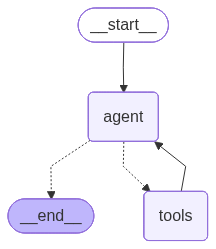

In [58]:
from typing import Literal

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph, MessagesState
from langgraph.prebuilt import ToolNode


tool_node = ToolNode(tools)
llm = model.bind_tools(tools)


def should_continue(state: MessagesState) -> Literal["tools", END]:
    messages = state['messages']
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END


def call_model(state: MessagesState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}


workflow = StateGraph(MessagesState)

workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")

workflow.add_conditional_edges(
    "agent",
    should_continue,
)

workflow.add_edge("tools", 'agent')

checkpointer = MemorySaver()

app = workflow.compile(checkpointer=checkpointer)

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

But with the same approach, we can create an application which connects different types of the workloads.   

Let's define the flow, which uses a list of logs from the application to analyze it and prepare a summary.

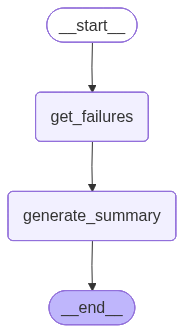

In [61]:
from typing import Optional, TypedDict, Annotated


class Logs(TypedDict):
    id: str
    question: str
    answer: str
    grade: Optional[int]
    feedback: Optional[str]

def add_logs(left: list[Logs], right: list[Logs]) -> list[Logs]:
    return left + right

class FailureAnalysisState(TypedDict):
    logs: Annotated[list[Logs], add_logs]
    failure_report: str
    failures: list[Logs]


def get_failures(state: FailureAnalysisState):
    return {"failures": "Error: failed to retrieve document"}


def generate_summary(state: FailureAnalysisState):
    failures = state["failures"]
    # Generate summary
    fa_summary = "Summary: failed to retrieve document"
    return {"failure_report": fa_summary}


failure_analysis_agent_builder = StateGraph(FailureAnalysisState)
failure_analysis_agent_builder.add_node("get_failures", get_failures)
failure_analysis_agent_builder.add_node("generate_summary", generate_summary)
failure_analysis_agent_builder.add_edge(START, "get_failures")
failure_analysis_agent_builder.add_edge("get_failures", "generate_summary")
failure_analysis_agent_builder.add_edge("generate_summary", END)
from IPython.display import Image, display
display(Image(failure_analysis_agent_builder.compile().get_graph().draw_mermaid_png()))

Let's review the graph.

Let's define the flow, which uses a list of logs from the application to find mostly hot topics.

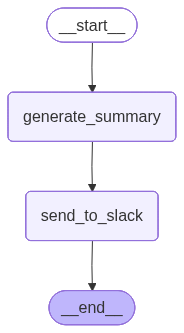

In [24]:
from typing import Annotated


class QuestionSummarizationState(TypedDict):
    summary_report: str
    logs: Annotated[list[Logs], add_logs]
    summary: str


def generate_summary(state: QuestionSummarizationState):
    docs = state["logs"]
    summary = "Questions focused on something."
    return {"summary": summary}


def send_to_slack(state: QuestionSummarizationState):
    summary = state["summary"]
    # NOTE: you can implement custom logic here, for example sending the summary generated in the previous step to Slack
    return {"summary_report": summary}


question_summary_agent_builder = StateGraph(QuestionSummarizationState)
question_summary_agent_builder.add_node("generate_summary", generate_summary)
question_summary_agent_builder.add_node("send_to_slack", send_to_slack)
question_summary_agent_builder.add_edge(START, "generate_summary")
question_summary_agent_builder.add_edge("generate_summary", "send_to_slack")
question_summary_agent_builder.add_edge("send_to_slack", END)
from IPython.display import Image, display
display(Image(question_summary_agent_builder.compile().get_graph().draw_mermaid_png()))

Check it. It is a simple graph.

And now let's combine all the graphs into one. As you can see we can use prepared graphs as nodes in the new graph.

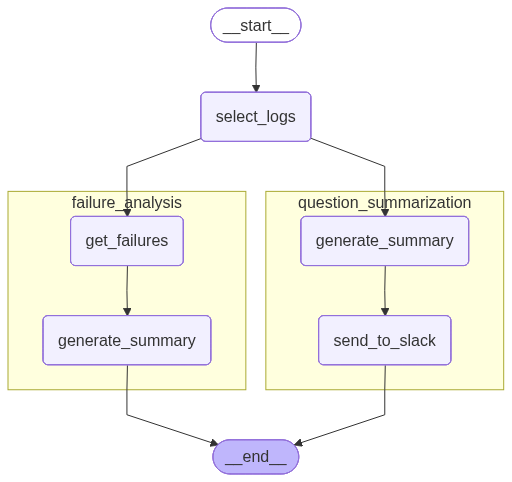

In [25]:
from typing import Annotated


class EntryGraphState(TypedDict):
    raw_logs: Annotated[list[Logs], add_logs]
    logs: Annotated[list[Logs], add_logs]  # This will be used in subgraphs
    failure_report: str  # This will be generated in the FA subgraph
    summary_report: str  # This will be generated in the QS subgraph

def select_logs(state):
    return {"logs": [log for log in state["raw_logs"] if "grade" in log]}

entry_builder = StateGraph(EntryGraphState)
entry_builder.add_node("select_logs", select_logs)
entry_builder.add_node("question_summarization", question_summary_agent_builder.compile())
entry_builder.add_node("failure_analysis", failure_analysis_agent_builder.compile())

entry_builder.add_edge(START, "select_logs")
entry_builder.add_edge("select_logs", "failure_analysis")
entry_builder.add_edge("select_logs", "question_summarization")
entry_builder.add_edge("failure_analysis", END)
entry_builder.add_edge("question_summarization", END)

full_graph = entry_builder.compile()     
from IPython.display import Image, display
display(Image(full_graph.get_graph(xray=1).draw_mermaid_png()))

Now you can see final result graph.

### CrewAI Agent models

CrewAI conceptual elements:  
- Agent  
- Task  
- Tool  
- Crew  
- Pipeline  
- Planning  
- Memory  

**Agent**: An agent is an autonomous unit programmed to:

1. Perform tasks  
2. Make decisions  
3. Communicate with other agents   
   
Think of an agent as a member of a team, with specific skills and a particular job to do. Agents can have different roles like 'Researcher', 'Writer', or 'Customer Support', each contributing to the overall goal of the crew.    

**Task**: A task is a specific job that an agent can perform. Tasks can be simple, like 'Summarize a text', or complex, like 'Write a blog post'.   

**Tool**: A tool is a piece of software that helps an agent perform a task.  This includes tools from the **crewAI Toolkit** and **LangChain Tools**, enabling everything from simple searches to complex interactions and effective teamwork among agents.  

**Crew**: A crew is a group of agents working together to achieve a common goal. Each agent in the crew has a specific role and set of tasks they can perform.  

**Pipeline**: Represents a structured workflow that allows for the sequential or parallel execution of multiple crews. It provides a way to organize complex processes involving multiple stages, where the output of one stage can serve as input for subsequent stages.  

**Planning**: Feature in CrewAI allows you to add planning capability to your crew.  

**Memory**: Sophisticated memory system designed to significantly enhance the capabilities of AI agents. This system comprises short-term memory, long-term memory, entity memory, and contextual memory, each serving a unique purpose in aiding agents to remember, reason, and learn from past interactions.  



In [26]:
# NOTE: crewai[tools]==0.41.1 does not exist on PyPI.
# Install the latest available version instead.
# CrewAI requires Python <=3.12 due to tiktoken wheels — skip on Python 3.13+.
# %pip install "crewai[tools]"

Out of the box, CrewAI provides a lot of tools for communication with external systems. For example, next tool can scrap any site. 

In [27]:
# NOTE: crewai not installed (requires Python <=3.12, tiktoken has no wheel for 3.13+)
# from crewai_tools import ScrapeWebsiteTool
# tool = ScrapeWebsiteTool(website_url='https://www.epam.com')
# text = tool.run()
# print(text)

In a real life we use different tools to perform different tasks. For example, we use a calculator to perform calculations, a dictionary to look up words, and a search engine to find information. Similarly, agents in CrewAI use tools to perform tasks. These tools can be simple, like a calculator, or complex, like a search engine.  

Also, we can extend the functionality of the CrewAI by adding new tools. 

In [28]:
# from crewai_tools import tool
#
# @tool("Generate Question")
# def question_tool(question: str) -> str:
#     """Tool generate question about web development."""
#     return "What is MVC pattern?"

Let's start with a bit complex example. We will create a crew of agents, each with a specific role and set of tasks they can perform.    

Define the agents:

In [29]:
# from crewai import Agent
#
# junior_developer = Agent(
#     role="Question Generator",
#     goal="Generate question about web development.",
#     backstory="Junior developer is a new team member who is eager to learn and help the team.",
#     verbose=True,
#     llm=model)
#
# senior_developer = Agent(
#     role="Answer Generator",
#     goal="Generate answer to the question.",
#     backstory="Senior developer is a team lead who is responsible for team management.",
#     llm=model
# )

Define the tasks and apply them for agents:


In [30]:
# from crewai import Task
#
# junior_developer_task = Task(
#     description="Generate any questions about software development.",
#     agent=junior_developer,
#     expected_output="Any questions about technical debt.",
# )
#
# senior_developer_task = Task(
#     description="Avoid answers.",
#     agent=senior_developer,
#     expected_output="Setup Meeting to discuss it.",
# )

So now, you can create a crew of agents and start the process. Please, review the output of the execution.

In [31]:
# from crewai import Crew, Process
#
# report_crew = Crew(
#   agents=[junior_developer, senior_developer],
#   tasks=[junior_developer_task, senior_developer_task],
#   process=Process.sequential
# )
#
# result = report_crew.kickoff()